# Basic

In [1]:
%load_ext autoreload
%autoreload all

In [2]:
import polars as pl
import pickle
import numpy as np
import tqdm
import os
import glob
import multiprocessing as mp

import src.graph_tokenizer_gd_tree_dev.config as config
import src.graph_tokenizer_gd_tree_dev.tokenizer as tokenizer
import src.graph_tokenizer_gd_tree_dev.eval as eval

In [3]:
metric_cols = ["semantic_coverage", "conciseness", "distance_score", "uniqueness_entropy",
               "unk_branche_rate", "uncovered_rate", "tree_complexity", "exact_rate", "unique_rate"]

# perf_df_all: greedy_tree_margin (6 lam values) + the baseline heuristics, straight from disk --
# robust to kernel restarts, and this is the persisted, confirmed-complete output of the
# (category, file_type, k) sweep in 4.eval_metrics.ipynb.
perf_df_base = pl.read_parquet(config.Results().perf_baseline_path).rename({"unk_rate": "unk_branche_rate"}).sort(["category", "file_type", "k"])
perf_df_greedy = pl.read_parquet(config.Results().perf_greedy_tree_path).rename({"unk_rate": "unk_branche_rate"}).sort(["category", "file_type", "k"])
perf_df_k_rnd = (pl.read_parquet(config.Results().perf_k_rdn_path)
                .rename({"unk_rate": "unk_branche_rate"})
                .group_by("category", "file_type", "k")
                .agg(pl.col(metric_cols).mean())
                .sort(["category", "file_type", "k"]))

# eigenvector_centrality is a degenerate baseline that always returns the same candidate set
# for all k, so it doesn't make sense to include it in the plots.
perf_df_all = pl.concat([perf_df_base, perf_df_greedy, perf_df_k_rnd], how="diagonal_relaxed").sort(["category", "file_type", "k"]).filter(pl.col("file_type") != "eigenvector_centrality")

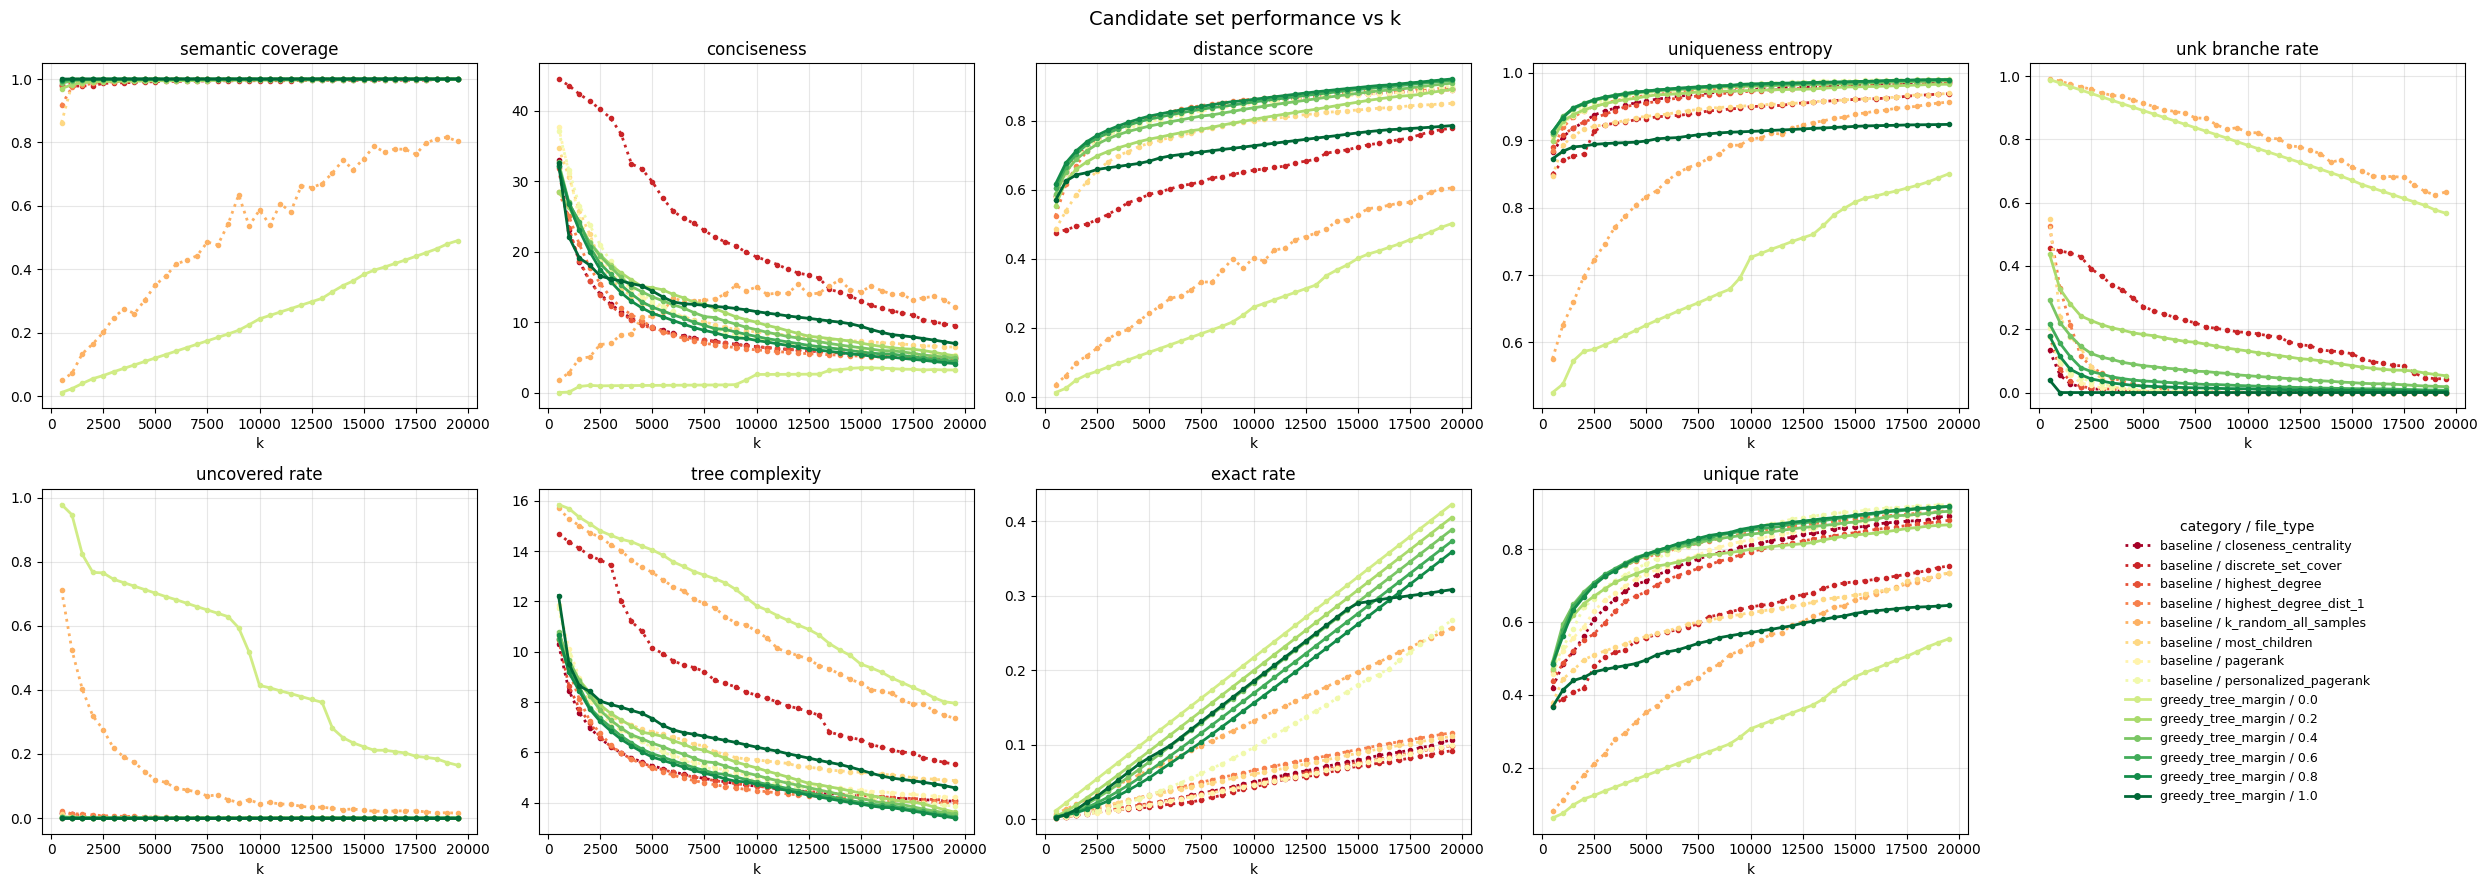

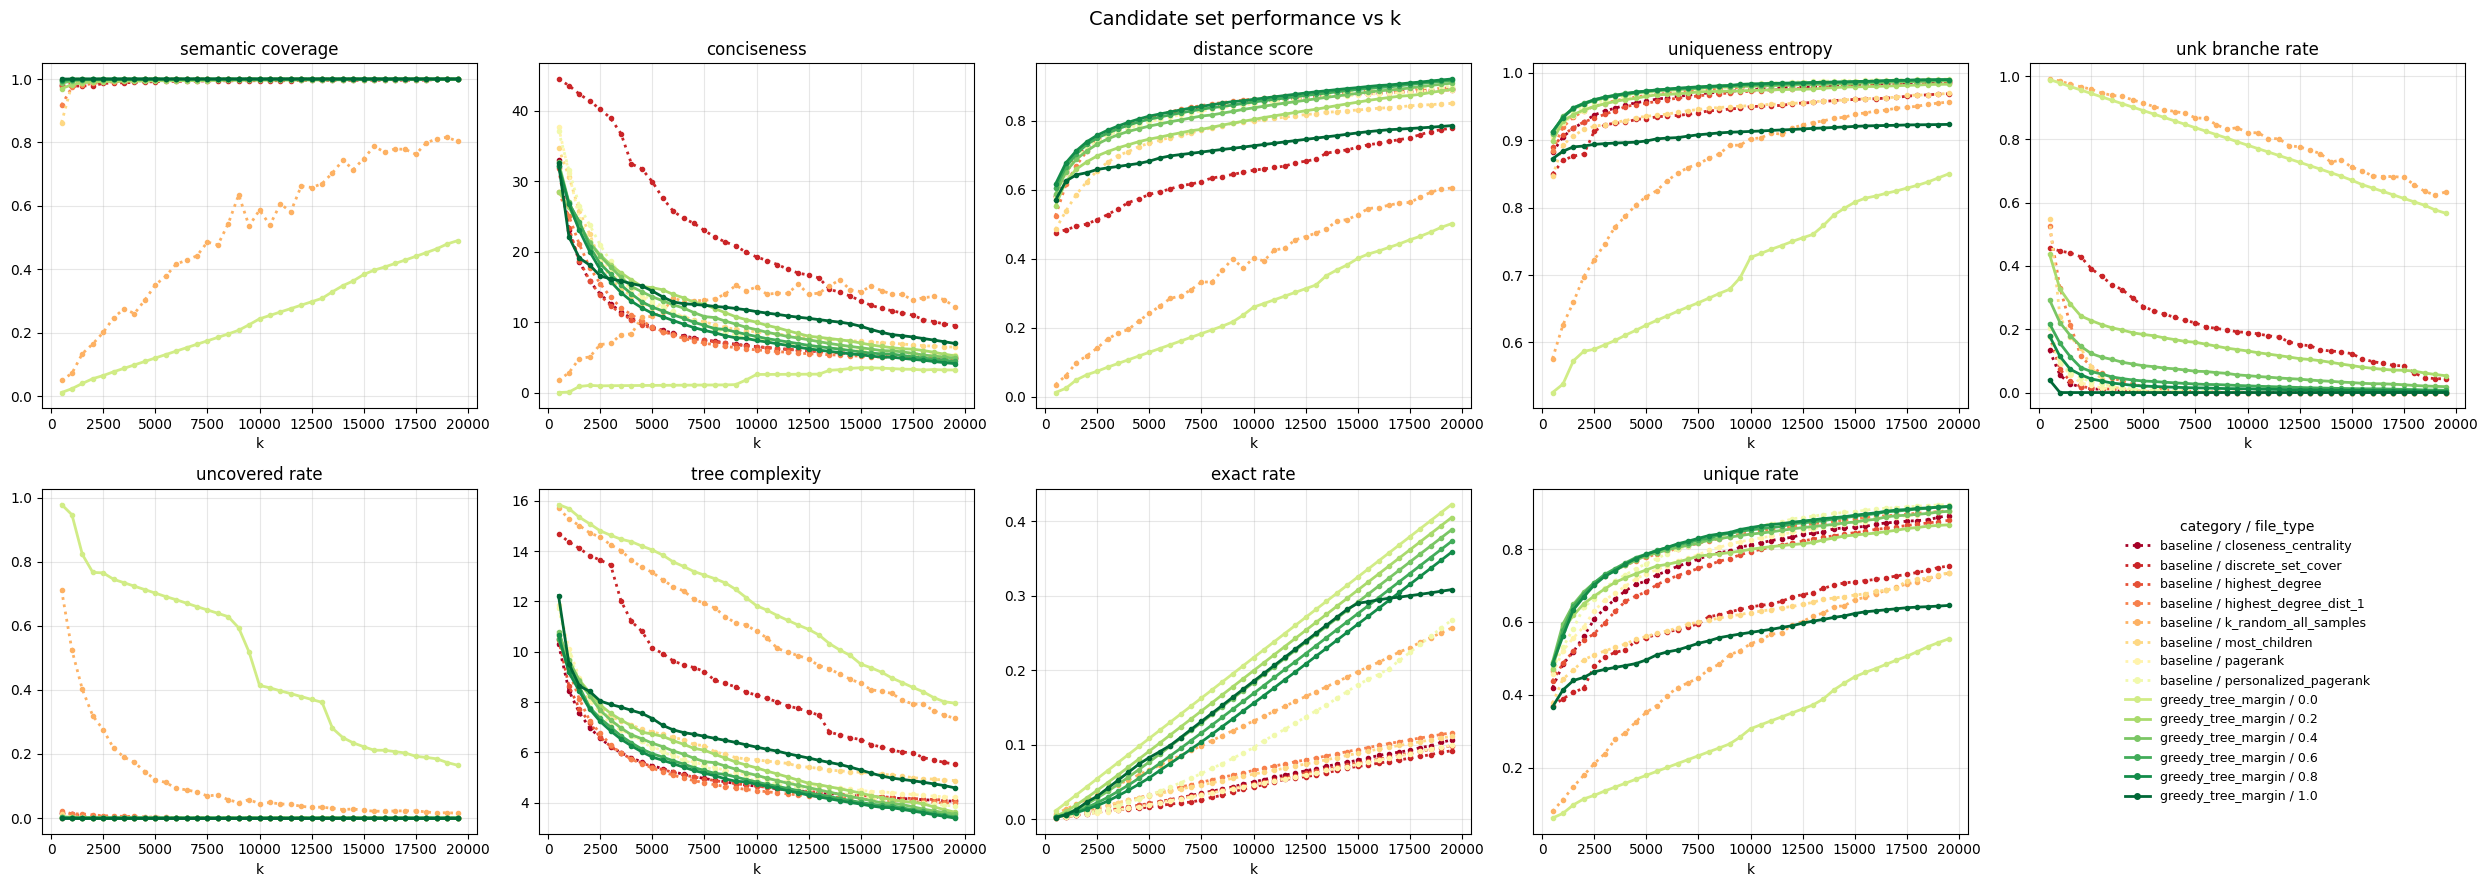

In [4]:
import matplotlib.pyplot as plt

def plot_candidate_performance(perf_df_all, metric_cols):
    """
    2x5 grid of metric-vs-k curves, one line per (category, file_type) series -- last slot
    holds the shared legend. Hue-varied ordinal ramp (red -> yellow -> green) keyed on sorted
    series order; baseline = dotted, greedy_tree_margin = solid, a second encoding on top of
    color so the two arms are distinguishable even without reading the legend.
    """
    series_keys = perf_df_all.select(["category", "file_type"]).unique().sort(["category", "file_type"]).rows()

    cmap = plt.get_cmap("RdYlGn")
    colors = {key: cmap(i / max(len(series_keys) - 1, 1)) for i, key in enumerate(series_keys)}
    linestyles = {key: (":" if key[0] == "baseline" else "-") for key in series_keys}

    fig, axes = plt.subplots(2, 5, figsize=(25, 9))
    axes = axes.flatten()

    for ax, metric in zip(axes, metric_cols):
        for category, file_type in series_keys:
            sub = perf_df_all.filter((pl.col("category") == category) & (pl.col("file_type") == file_type))
            ax.plot(sub["k"], sub[metric], color=colors[(category, file_type)], linestyle=linestyles[(category, file_type)],
                     linewidth=2, marker="o", markersize=3)
        ax.set_title(metric.replace("_", " "))
        ax.set_xlabel("k")
        ax.grid(alpha=0.3)

    axes[-1].axis("off")  # 10th slot unused by metrics -- holds the shared legend instead
    handles = [
        plt.Line2D([0], [0], color=colors[key], linestyle=linestyles[key], lw=2, marker="o", markersize=4,
                   label=f"{key[0]} / {key[1]}")
        for key in series_keys
    ]
    axes[-1].legend(handles=handles, loc="center", fontsize=9, title="category / file_type", frameon=False)

    fig.suptitle("Candidate set performance vs k", fontsize=14)
    fig.tight_layout()
    return fig


plot_candidate_performance(perf_df_all, metric_cols)

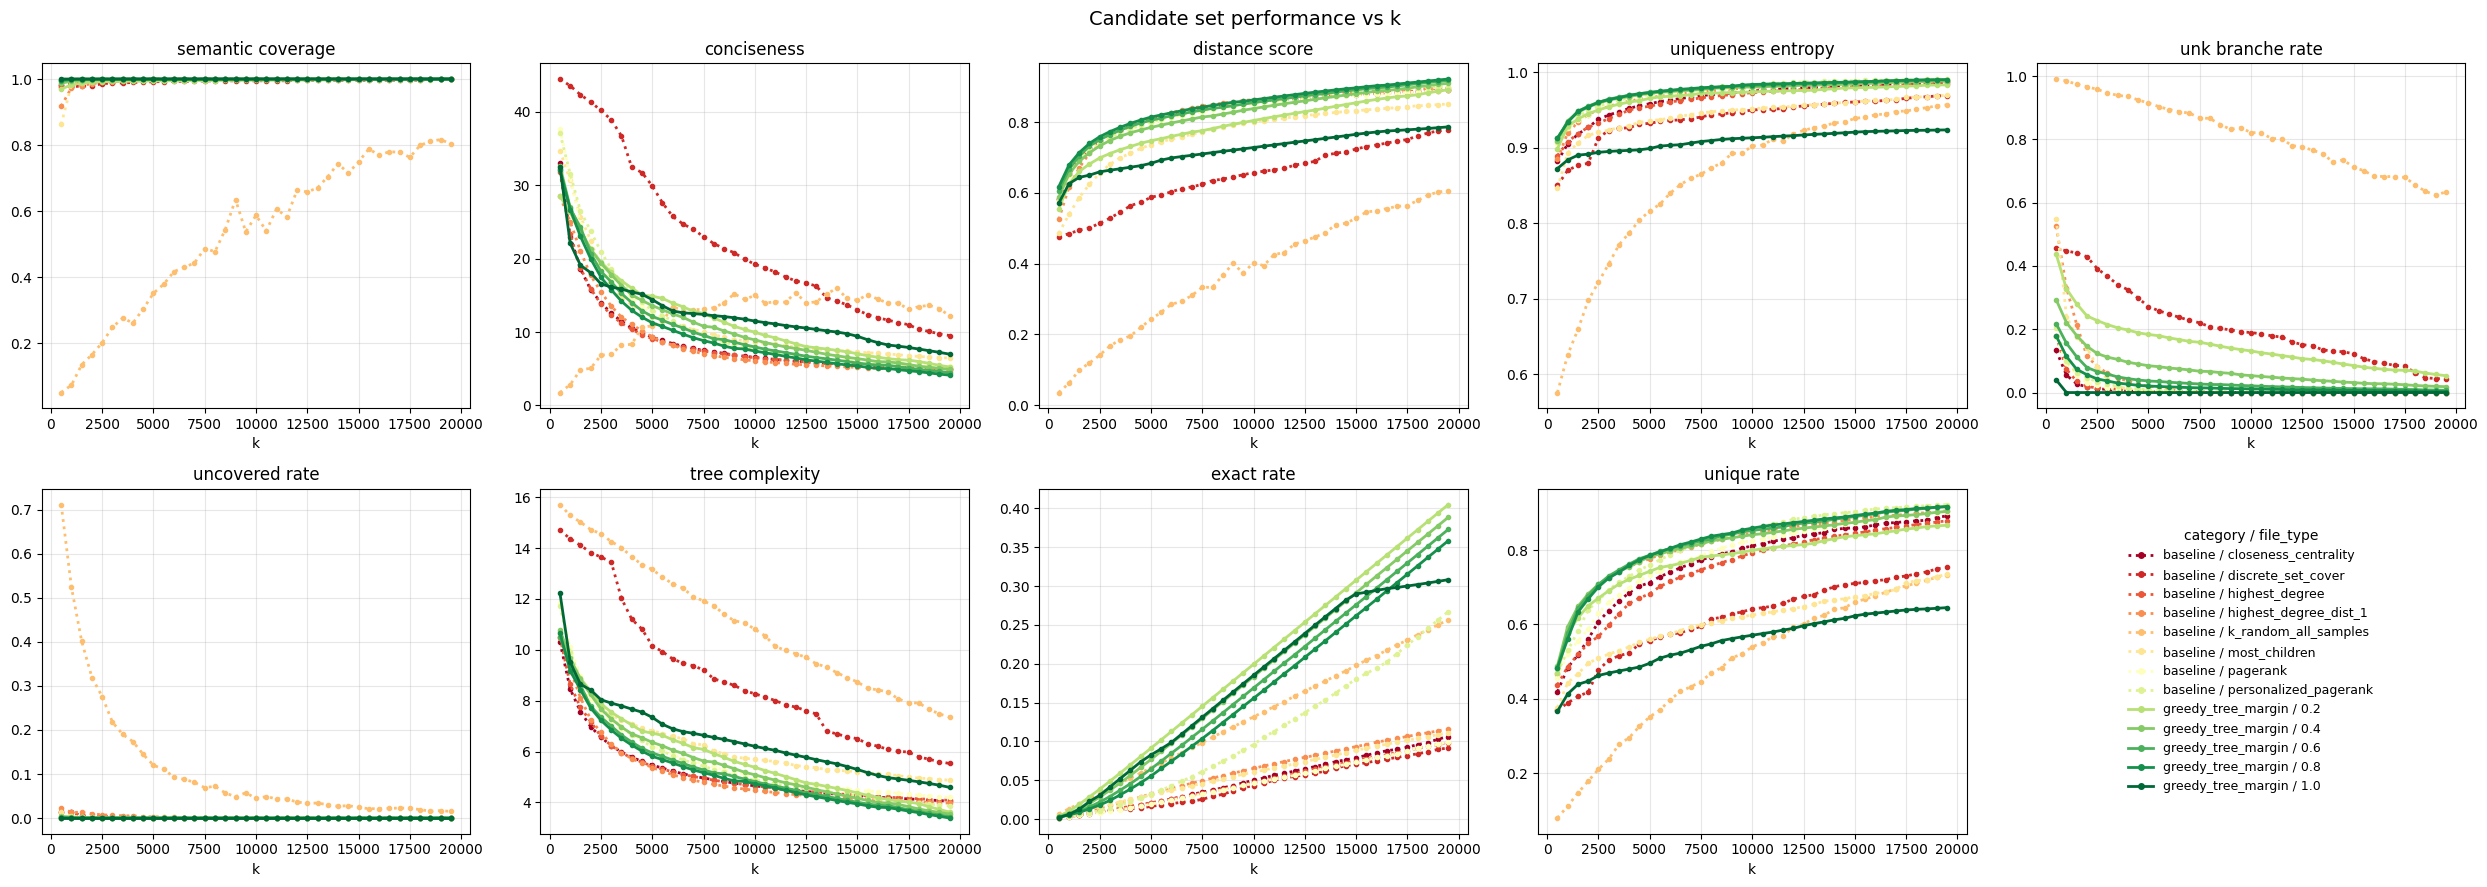

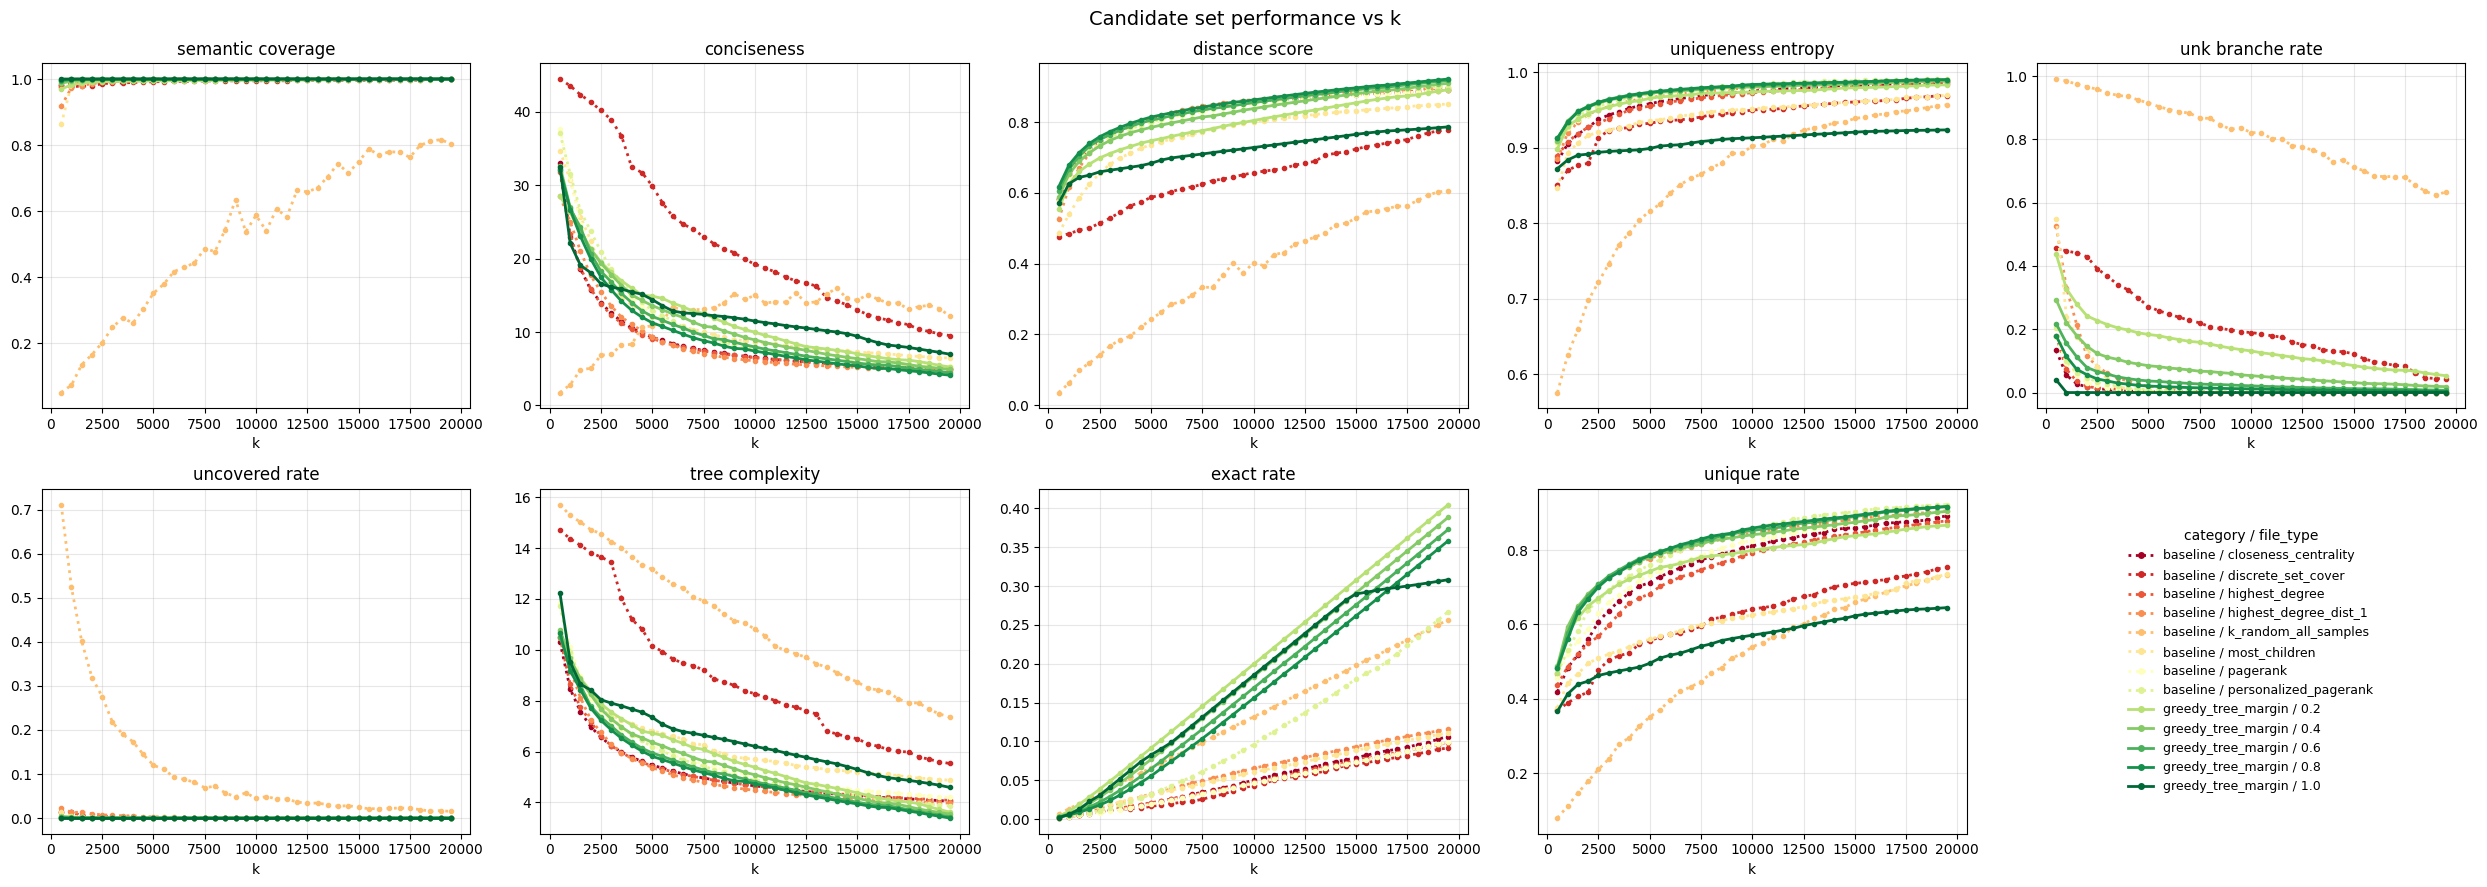

In [5]:
plot_candidate_performance(perf_df_all.filter(pl.col("file_type") != "0.0"), metric_cols)

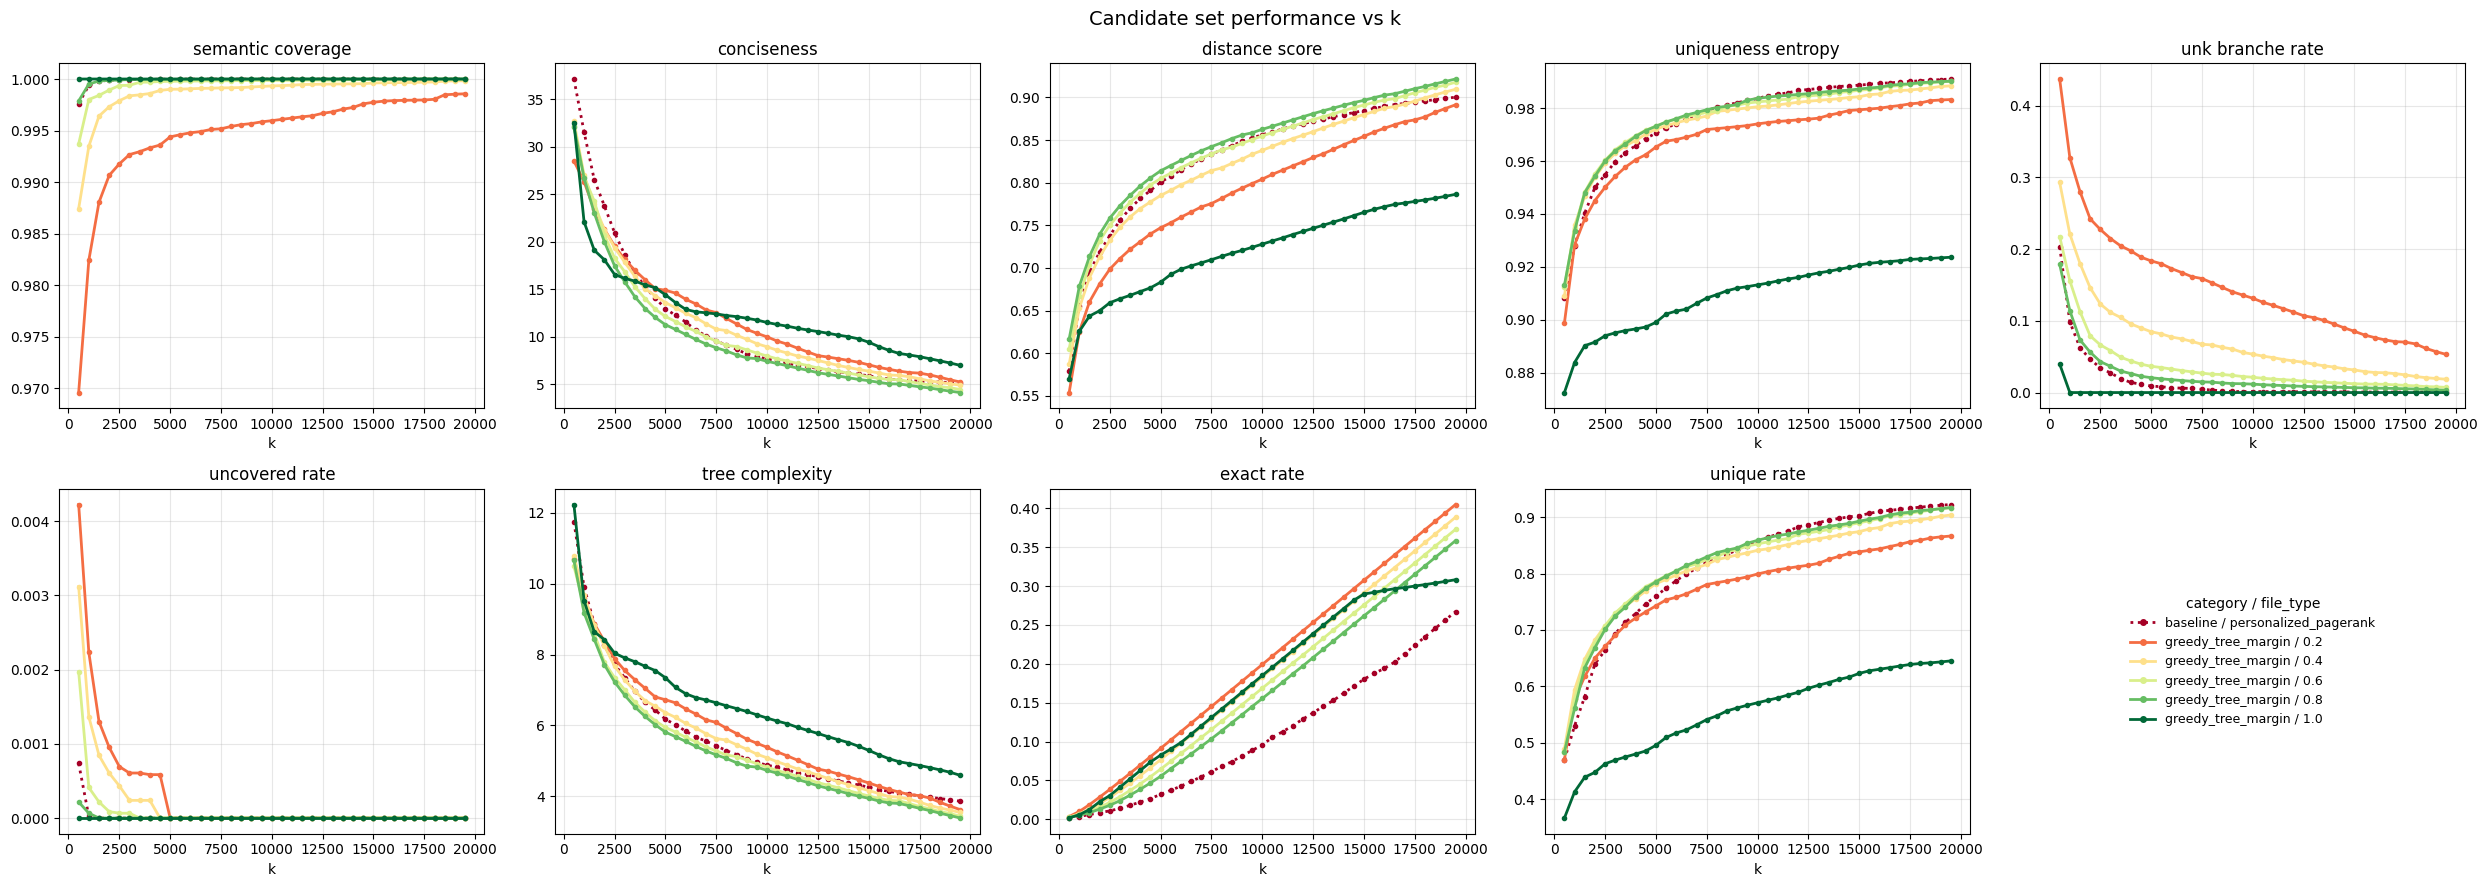

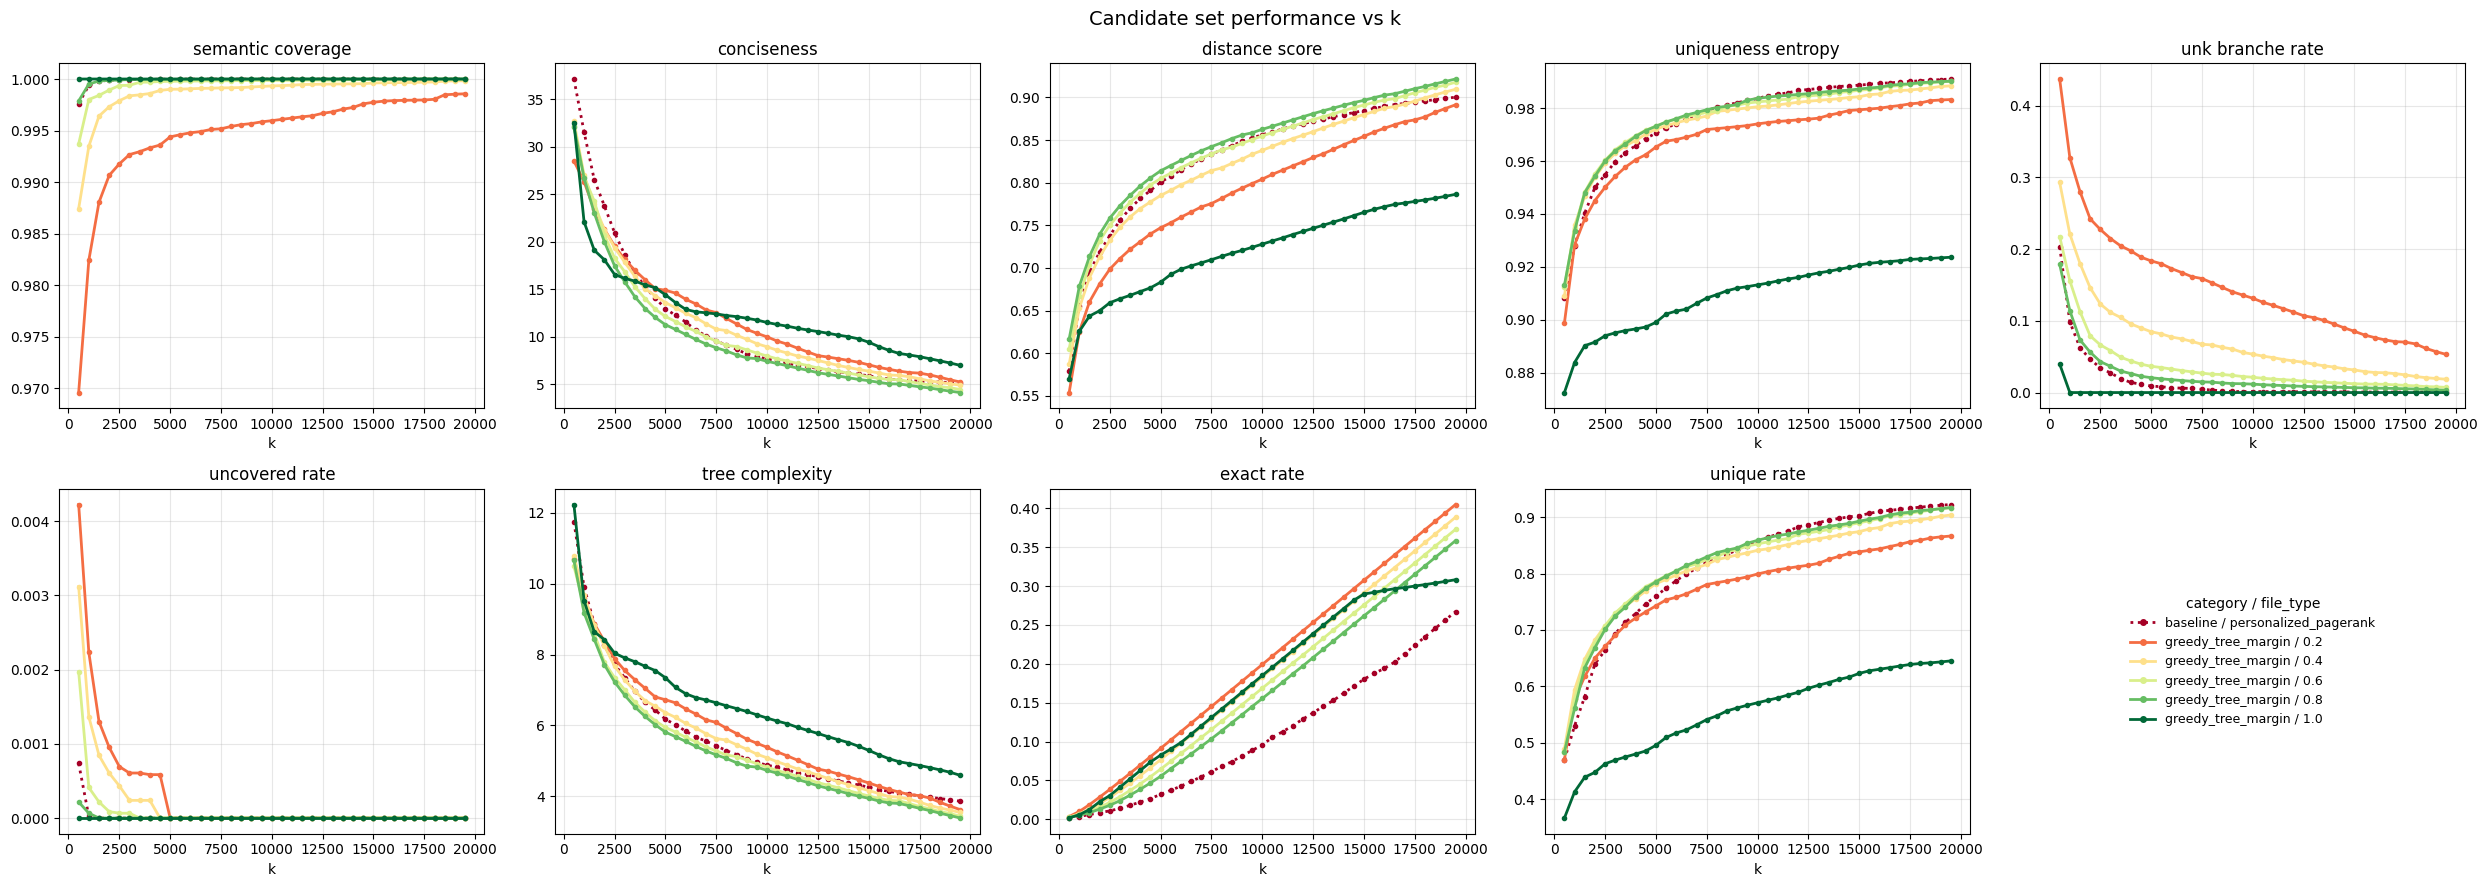

In [6]:
plot_candidate_performance(perf_df_all.filter(((pl.col("category") == "greedy_tree_margin") | (pl.col("file_type") == "personalized_pagerank")) & (pl.col("file_type") != "0.0")), metric_cols)
